In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!pip3 install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 5.4 MB/s eta 0:00:00


In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import sys
from glob import glob
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

## Load in Data

In [ ]:
path = "/content/gdrive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_imu_sensor_df.csv"

interpolated_final_df = pd.read_csv(path)

In [ ]:
lower_body_imu_sensor_locations = ['Pelvis', 'RightUpperLeg', 'LeftUpperLeg', 'RightLowerLeg', 'LeftLowerLeg', 'RightFoot', 'LeftFoot']

In [ ]:
# retain the sensors that are in the luo_imu_sensor_locations list
interpolated_final_df = interpolated_final_df[interpolated_final_df['sensor_location'].isin(lower_body_imu_sensor_locations)]

In [ ]:
# normalize each measurement column
interpolated_final_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']] = interpolated_final_df[['acceleration_x', 'acceleration_y', 'acceleration_z', 'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].apply(lambda x: (x - x.mean()) / x.std())

In [ ]:
# extracting variables from the gait_cycle_id column
interpolated_final_df['participant_id'] = interpolated_final_df['gait_cycle_id'].str.split('_').str[0]
interpolated_final_df['left_gait_cycle'] = interpolated_final_df['gait_cycle_id'].str.split('_').str[1]
interpolated_final_df['task'] = interpolated_final_df['gait_cycle_id'].str.split('_').str[2]

In [ ]:
# assign numerical values to these original string values
le = LabelEncoder()
interpolated_final_df['task'] = le.fit_transform(interpolated_final_df['task'])
interpolated_final_df['walk_mode'] = le.fit_transform(interpolated_final_df['walk_mode'])

In [ ]:
# Define columns to be converted to integers, excluding sensor_location and gait_cycle_id
columns_to_convert = ['participant_id', 'task', 'time', 'walk_mode']

# Convert specified columns to integer
interpolated_final_df[columns_to_convert] = interpolated_final_df[columns_to_convert].astype(int)

# Handle 'left_gait_cycle' separately (convert only the part before the decimal)
interpolated_final_df['left_gait_cycle'] = (
    interpolated_final_df['left_gait_cycle']
    .str.split('.')
    .str[0]
    .astype(int)
)


In [ ]:
interpolated_final_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [ ]:
import random

number_list = list(interpolated_final_df['participant_id'].unique())
# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 2)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 2)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

[24, 13]
[23, 25]
[1, 2, 3, 4, 5, 7, 8, 10, 12, 14, 15, 16, 17, 18, 19, 22]


In [ ]:
train = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(train_list)]
val = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(val_three_numbers)]
test = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(test_three_numbers)]

In [ ]:
# retain only the first instance of gait_cycle_id
train_gc = train.drop_duplicates(subset=['gait_cycle_id'], keep='first')

In [ ]:
# count how many unique gait cycle ids are in each walk mode
train_gc[['walk_mode']].value_counts()

,count
walk_mode,
4,13781
0,4510
1,3289
3,1669
2,895


In [ ]:
# Oversample smaller classes to balance the dataset
min_samples = int(train_gc['walk_mode'].value_counts().min())

In [ ]:
min_samples

895

In [ ]:
# Downsample to balance classes
balanced_gait_cycles = (
    train_gc.groupby('walk_mode')
    .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))
    .reset_index(drop=True)
)

<ipython-input-21-20f7be106a20>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))


In [ ]:
print(balanced_gait_cycles['walk_mode'].value_counts())

walk_mode
0    895
1    895
2    895
3    895
4    895
Name: count, dtype: int64


In [ ]:
filtered_interpolated_final_df = pd.merge(
    train,
    balanced_gait_cycles[['gait_cycle_id']],
    on='gait_cycle_id',
    how='inner'
)

In [ ]:
train = filtered_interpolated_final_df.copy()

In [ ]:
le = LabelEncoder()

train['gait_cycle_id'] = le.fit_transform(train['gait_cycle_id'])
train['sensor_location'] = le.fit_transform(train['sensor_location'])
train['task'] = le.fit_transform(train['task'])
train['walk_mode'] = le.fit_transform(train['walk_mode'])

val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
val['sensor_location'] = le.fit_transform(val['sensor_location'])
val['task'] = le.fit_transform(val['task'])
val['walk_mode'] = le.fit_transform(val['walk_mode'])

test['gait_cycle_id'] = le.fit_transform(test['gait_cycle_id'])
test['sensor_location'] = le.fit_transform(test['sensor_location'])
test['task'] = le.fit_transform(test['task'])
test['walk_mode'] = le.fit_transform(test['walk_mode'])

<ipython-input-25-b990848ca3d9>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
<ipython-input-25-b990848ca3d9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['sensor_location'] = le.fit_transform(val['sensor_location'])
<ipython-input-25-b990848ca3d9>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [ ]:
train['walk_mode'].value_counts()

,count
walk_mode,
2,501200
4,501200
3,501200
0,501200
1,501200


In [ ]:
def preprocess_data(df):
    # Initialize a list to hold data for each sensor location
    sensor_data_dict = {sensor: [] for sensor in df['sensor_location'].unique()}
    all_labels_y = []  # For storing labels for each gait cycle

    for gait_cycle_id, group_data in df.groupby('gait_cycle_id'):
        # Sort by time to ensure consistent order
        group_data = group_data.sort_values(by='time')

        # Process each sensor location
        for sensor_location, sensor_group in group_data.groupby('sensor_location'):
            # Extract the six IMU features
            sensor_array = sensor_group[['acceleration_x', 'acceleration_y', 'acceleration_z',
                                         'angularVelocity_x', 'angularVelocity_y', 'angularVelocity_z']].values

            # Pad or truncate to ensure length of 80
            if len(sensor_array) < 80:
                padding = np.zeros((80 - len(sensor_array), 6))  # Pad with 6 zeros
                sensor_array = np.vstack([sensor_array, padding])
            elif len(sensor_array) > 80:
                sensor_array = sensor_array[:80]

            # Append the processed sensor data for the current sensor location
            sensor_data_dict[sensor_location].append(sensor_array)

        # Extract walk mode labels for the gait cycle
        walk_mode_data = group_data['walk_mode'].values[:80]
        if len(walk_mode_data) < 80:
            walk_mode_data = np.pad(walk_mode_data, (0, 80 - len(walk_mode_data)), constant_values=-1)  # Use -1 for padding
        all_labels_y.append(walk_mode_data)

    # Convert sensor data for each sensor location into a NumPy array with shape [x, 80, 6]
    all_sensor_data = [np.array(sensor_data_dict[sensor]) for sensor in sorted(sensor_data_dict.keys())]

    # Convert labels to a NumPy array with shape [x, 80]
    all_labels_x = np.array(all_sensor_data)
    all_labels_y = np.array(all_labels_y)  # Shape: [x, 80]

    return all_sensor_data, all_labels_y


In [ ]:
train_all_data_x, train_all_labels_y = preprocess_data(train)

In [ ]:
val_all_data_x, val_all_labels_y = preprocess_data(val)

In [ ]:
test_all_data_x, test_all_labels_y = preprocess_data(test)

In [ ]:
train_all_data_x_np = np.array(train_all_data_x)
val_all_data_x_np = np.array(val_all_data_x)
test_all_data_x_np = np.array(test_all_data_x)

In [ ]:
train_all_labels_y = np.swapaxes(train_all_labels_y, 0, 1)
train_all_labels_y = train_all_labels_y[0]

val_all_labels_y = np.swapaxes(val_all_labels_y, 0, 1)
val_all_labels_y = val_all_labels_y[0]

test_all_labels_y = np.swapaxes(test_all_labels_y, 0, 1)
test_all_labels_y = test_all_labels_y[0]

In [ ]:
from keras.utils import to_categorical

# Assuming the labels are already numeric
train_all_labels_y = to_categorical(train_all_labels_y)
val_all_labels_y = to_categorical(val_all_labels_y)
test_all_labels_y = to_categorical(test_all_labels_y)

In [ ]:
train_all_labels_y[0]

array([0., 0., 1., 0., 0.])

In [ ]:
train_all_data_x_np.shape, train_all_labels_y.shape, val_all_data_x_np.shape, val_all_labels_y.shape, test_all_data_x_np.shape, test_all_labels_y.shape

((7, 4475, 80, 6),
 (4475, 5),
 (7, 3191, 80, 6),
 (3191, 5),
 (7, 3129, 80, 6),
 (3129, 5))

In [ ]:
train_all_data_x_np.shape, train_all_labels_y.shape

((7, 4475, 80, 6), (4475, 5))

In [ ]:
val_all_data_x_np.shape, val_all_labels_y.shape

((7, 3191, 80, 6), (3191, 5))

In [ ]:
test_all_data_x_np.shape, test_all_labels_y.shape

((7, 3129, 80, 6), (3129, 5))

In [ ]:
train_X = train_all_data_x_np
train_Y = train_all_labels_y

val_X = val_all_data_x_np
val_Y = val_all_labels_y

test_X = test_all_data_x_np
test_Y = test_all_labels_y

In [ ]:
n_obs, n_timesteps, n_features, n_classes = train_X[0].shape[0], train_X[0].shape[1], train_X[0].shape[2], train_Y.shape[1]

In [ ]:
n_obs, n_timesteps, n_features, n_classes

(4475, 80, 6, 5)

In [ ]:
train_X_list = [train_all_data_x_np[i] for i in range(train_all_data_x_np.shape[0])]
train_Y_list = [train_all_labels_y for i in range(train_all_data_x_np.shape[0])]

val_X_list = [val_all_data_x_np[i] for i in range(val_all_data_x_np.shape[0])]
val_Y_list = [val_all_labels_y for i in range(val_all_data_x_np.shape[0])]

test_X_list = [test_all_data_x_np[i] for i in range(test_all_data_x_np.shape[0])]

test_Y_list = [test_all_labels_y for i in range(test_all_data_x_np.shape[0])]

# Print the shape of each item in the list to verify
for idx, sensor_data in enumerate(train_X_list):
    print(f"Sensor {idx+1} shape: {sensor_data.shape}")
    print(f"Label {idx+1} shape: {train_Y_list[idx].shape}")
    print()


Sensor 1 shape: (4475, 80, 6)
Label 1 shape: (4475, 5)

Sensor 2 shape: (4475, 80, 6)
Label 2 shape: (4475, 5)

Sensor 3 shape: (4475, 80, 6)
Label 3 shape: (4475, 5)

Sensor 4 shape: (4475, 80, 6)
Label 4 shape: (4475, 5)

Sensor 5 shape: (4475, 80, 6)
Label 5 shape: (4475, 5)

Sensor 6 shape: (4475, 80, 6)
Label 6 shape: (4475, 5)

Sensor 7 shape: (4475, 80, 6)
Label 7 shape: (4475, 5)



## hyperparameter tuning

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.3 MB/s eta 0:00:00


In [ ]:
# Clears the session for TensorFlow
tf.keras.backend.clear_session()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, BatchNormalization
from tensorflow.keras.layers import Bidirectional, LSTM, Attention, Concatenate, Dense, Flatten
import keras_tuner as kt

# hyperparameter tuning
def build_model(hp):
    input_shape = (n_timesteps, n_features)
    number_of_sensors = len(train_X_list)
    inputs = []
    branches = []

    for _ in range(number_of_sensors):
        input_layer = Input(shape=input_shape)
        inputs.append(input_layer)

        # CNN layer
        cnn_out = BatchNormalization()(input_layer)
        cnn_out = Conv1D(
            filters=hp.Int('filters', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('kernel_size', values=[3, 5]),
            activation='relu'
        )(cnn_out)
        cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
        cnn_out = Dropout(hp.Float('cnn_dropout', 0.3, 0.5, step=0.05))(cnn_out)

        # Bidirectional LSTM layer
        lstm_out = Bidirectional(LSTM(
            units=hp.Int('lstm_units', min_value=64, max_value=256, step=64),
            dropout=hp.Float('lstm_dropout', 0.3, 0.5, step=0.05),
            recurrent_dropout=hp.Float('recurrent_dropout', 0.3, 0.5, step=0.05),
            return_sequences=True  # Return sequences for Attention layer
        ))(cnn_out)

        # Attention layer
        attention = Attention()([lstm_out, lstm_out])
        merged = Concatenate(axis=-1)([lstm_out, attention])  # Concatenate attention output with LSTM output
        # Dense layer for individual branch output (removed softmax activation)
        output_branch = Dense(n_classes)(merged)
        branches.append(output_branch)

    # Concatenate the outputs of all branches along the feature axis
    merged_output = Concatenate(axis=-1)(branches)

    # MLP layer
    mlp_out = Flatten()(merged_output)
    mlp_out = Dense(
        units=hp.Int('dense1_units', min_value=64, max_value=256, step=64),
        activation='relu'
    )(mlp_out)
    mlp_out = Dense(
        units=hp.Int('dense2_units', min_value=32, max_value=128, step=32),
        activation='relu'
    )(mlp_out)

    # Output layer with softmax activation for multi-class classification
    output_layer = Dense(n_classes, activation='softmax')(mlp_out)

    model = Model(inputs=inputs, outputs=output_layer)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Hyperparameter tuning (updated to use a single target array)
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=20,
    factor=3,
    directory='my_tuning',
    project_name='GC_seg_Insole_cnn_lstm_tuning'
)

# Run the tuner with train_Y instead of train_Y_list
tuner.search(train_X_list, train_Y, epochs=20, validation_data=(val_X_list, val_Y), callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)])

# Get the best model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
# best_model = tuner.hypermodel.build(best_hps)

Trial 30 Complete [00h 11m 54s]
val_loss: 0.3211614191532135

Best val_loss So Far: 0.23183263838291168
Total elapsed time: 06h 33m 59s


## Train Model

In [ ]:
# build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)
#print the summary of the model
best_model.summary()

In [ ]:
# Build the model with the best hp
model = build_model(best_hps)

# Fit with the entire dataset
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(train_X_list, train_Y, epochs=200, batch_size=128, callbacks=[callback], validation_data=(val_X_list, val_Y))

Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 196s 3s/step - accuracy: 0.4784 - loss: 1.2613 - val_accuracy: 0.5841 - val_loss: 0.9457
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.7622 - loss: 0.6125 - val_accuracy: 0.6346 - val_loss: 0.7820
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8364 - loss: 0.4554 - val_accuracy: 0.8082 - val_loss: 0.5435
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.8726 - loss: 0.3444 - val_accuracy: 0.8327 - val_loss: 0.4293
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8845 - loss: 0.3205 - val_accuracy: 0.8850 - val_loss: 0.3205
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.8973 - loss: 0.2779 - val_accuracy: 0.8875 - val_loss: 0.3799
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9129 - loss: 0.2441 - val_accuracy: 0.8972 - val_loss: 0.3272
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 98s 3s/step - accuracy: 0.9195 - loss: 0.2217 - val_accuracy: 0.9010 -

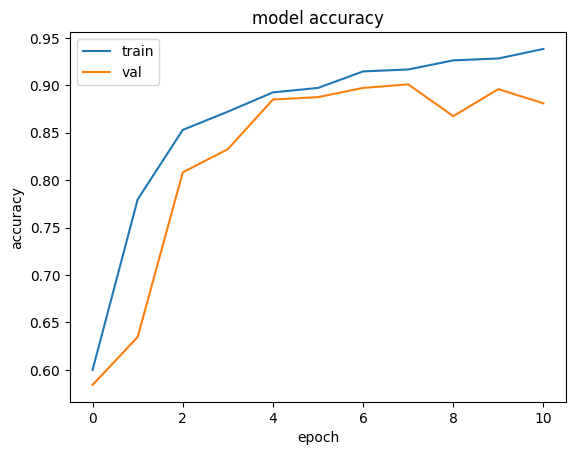

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

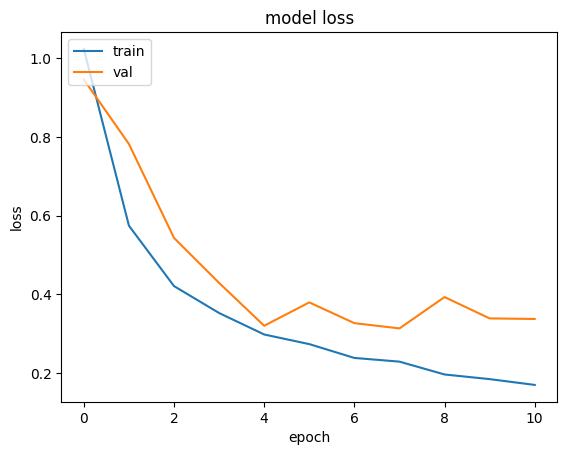

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_X_list, test_Y)

98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 218ms/step - accuracy: 0.7570 - loss: 0.7130


In [ ]:
# Check shapes of test data before evaluation
print("Test X shape:", test_X_list[0].shape)
print("Test Y shape:", test_Y_list[0].shape)

Test X shape: (3129, 80, 6)
Test Y shape: (3129, 5)


In [ ]:
#predictions
predictions = model.predict(test_X_list)

98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 326ms/step


In [ ]:
# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=-1)

# Convert true labels to class labels (if needed)
true_classes = tf.argmax(test_Y, axis=-1)

# Calculate accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32))
print(f"Test accuracy: {accuracy.numpy() * 100:.2f}%")

# Display predicted and true classes for further inspection
print("Predicted classes:", predicted_classes.numpy())
print("True classes:", true_classes.numpy())

Test accuracy: 81.56%
Predicted classes: [1 4 3 ... 0 4 4]
True classes: [4 4 4 ... 0 4 4]


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score

# Convert predictions and true labels to NumPy arrays
# The variables are already numpy arrays, so no conversion is needed.
predicted_classes_np = np.array(predicted_classes)
true_classes_np = np.array(true_classes)

# Generate a classification report (includes precision, recall, F1-score for each class)
report = classification_report(true_classes_np, predicted_classes_np, digits=4)

print("Classification Report:\n", report)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes_np, predicted_classes_np)
print("Confusion Matrix:\n", conf_matrix)

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")
f1 = f1_score(true_classes_np, predicted_classes_np, average='weighted')
# overall F1 score average
overall_F1 = round(math.fsum(f1_scores) / len(f1_scores),2)
print(f"Overall F1 Score: {overall_F1}")



Classification Report:
               precision    recall  f1-score   support

           0     0.7817    0.8678    0.8225       590
           1     0.8283    0.9203    0.8719       414
           2     0.3534    0.9248    0.5114       133
           3     0.8253    0.8672    0.8457       256
           4     0.9406    0.7569    0.8388      1736

    accuracy                         0.8156      3129
   macro avg     0.7459    0.8674    0.7781      3129
weighted avg     0.8614    0.8156    0.8268      3129

Confusion Matrix:
 [[ 512    2   52    0   24]
 [   0  381    0    3   30]
 [   2    0  123    0    8]
 [   1    4    8  222   21]
 [ 140   73  165   44 1314]]
F1-Scores (per class): [0.86779661 0.92028986 0.92481203 0.8671875  0.75691244]
Overall F1 Score: 0.87


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# calculate class sensitivity and specificity as well as the overall values
res = []
for l in [0,1,2,3,4]:
     prec,recall,_,_ = precision_recall_fscore_support(np.array(true_classes_np)==l,
                                                  np.array(predicted_classes_np)==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

sens_spes = pd.DataFrame(res,columns = ['class','specificity','sensitivity'])
print(sens_spes)

overall_specificity = sens_spes['specificity'].mean()
overall_sensitivity = sens_spes['sensitivity'].mean()
print(f"Overall specificity: {round(overall_specificity,2)}")
print(f"Overall sensitivity: {round(overall_sensitivity, 2)}")

   class  specificity  sensitivity
0      0     0.943679     0.867797
1      1     0.970902     0.920290
2      2     0.924900     0.924812
3      3     0.983641     0.867188
4      4     0.940416     0.756912
Overall specificity: 0.95
Overall sensitivity: 0.87


## Confusion Matrix

In [ ]:
# define variables for confusion matrix
true_classes = true_classes.numpy()
predicted_classes = predicted_classes.numpy()

In [ ]:
# Compute the confusion matrix
result = confusion_matrix(true_classes, predicted_classes)

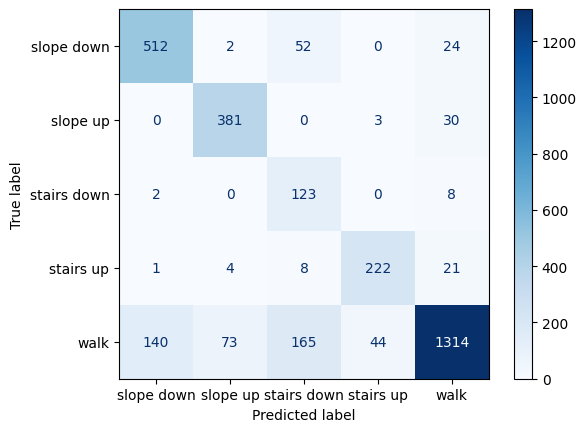

In [ ]:
# plot confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'])

cm_display.plot(cmap=plt.cm.Blues)
plt.show()

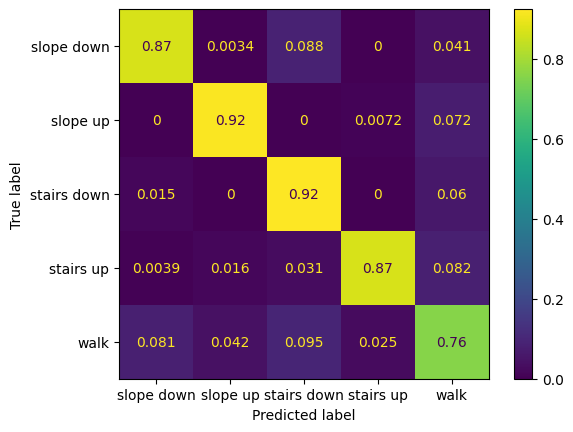

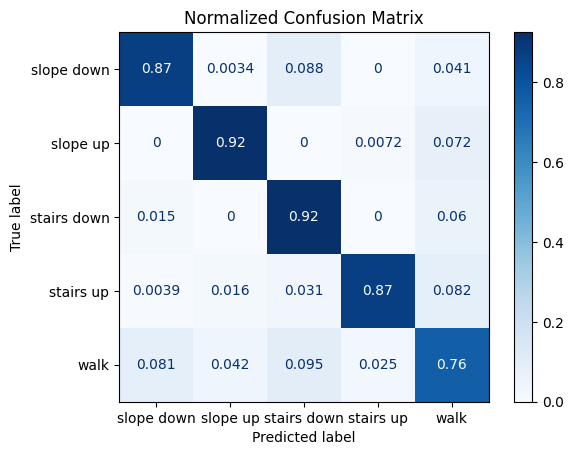

In [ ]:
# Create the normalized confusion matrix display using the from_predictions method
cm_display = ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'],
    normalize='true'  # Normalize by the true labels
)

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()